# Système de recommandation de films — Content-based, Collaboratif & Hybride

**Objectif du projet** : construire et comparer trois approches de recommandation sur le jeu de
données [MovieLens](https://movielens.org/) (small) : 100 836 notes, 9 742 films, 610 utilisateurs.

1. **Content-based filtering** : recommander des films similaires en se basant sur leurs
   caractéristiques (genres).
2. **Collaborative filtering** : recommander des films en se basant sur les notes données par
   des utilisateurs aux comportements similaires (factorisation matricielle / SVD).
3. **Système hybride** : combiner les deux pour obtenir des recommandations à la fois
   pertinentes (contenu) et personnalisées (comportement).

Chaque section explique la notion avant de l'implémenter.

## 0. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split

pd.set_option("display.max_colwidth", 80)
np.random.seed(42)

DATA_DIR = "../data"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

In [2]:
movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")

print("movies :", movies.shape)
print("ratings :", ratings.shape)
movies.head()

movies : (9742, 3)
ratings : (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 1. Exploration rapide des données (EDA)

Avant de modéliser quoi que ce soit, on regarde toujours à quoi ressemblent les données :
combien d'utilisateurs, combien de films, à quel point la matrice utilisateur × film est
"remplie" (c'est la **sparsité**, un concept central en recommandation : la plupart des
utilisateurs n'ont noté qu'une infime fraction des films disponibles).

In [4]:
n_users = ratings["userId"].nunique()
n_movies = movies["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Utilisateurs uniques : {n_users}")
print(f"Films uniques        : {n_movies}")
print(f"Notes totales        : {n_ratings}")
print(f"Sparsité de la matrice utilisateur-film : {sparsity:.4%}")
print(f"-> chaque utilisateur n'a noté en moyenne que {n_ratings/n_users:.1f} films sur {n_movies}")

Utilisateurs uniques : 610
Films uniques        : 9742
Notes totales        : 100836
Sparsité de la matrice utilisateur-film : 98.3032%
-> chaque utilisateur n'a noté en moyenne que 165.3 films sur 9742


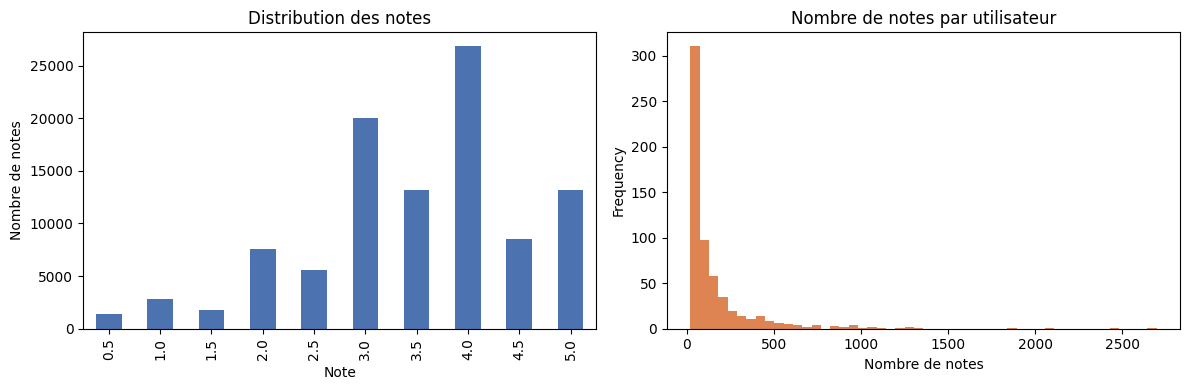

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de notes")

ratings.groupby("userId").size().plot(kind="hist", bins=50, ax=axes[1], color="#DD8452")
axes[1].set_title("Nombre de notes par utilisateur")
axes[1].set_xlabel("Nombre de notes")

plt.tight_layout()
plt.savefig("../models/eda_distributions.png", dpi=100)
plt.show()

La plupart des notes sont entre 3 et 4 étoiles (biais classique : les gens notent surtout ce
qu'ils ont apprécié), et la distribution du nombre de notes par utilisateur est très étalée
(quelques utilisateurs très actifs, beaucoup d'utilisateurs proches du minimum de 20 notes
imposé lors de la construction du dataset).

## 2. Content-based filtering

**Principe** : on décrit chaque film par ses caractéristiques (ici les genres), on transforme
cette description en vecteur numérique, puis on calcule à quel point deux films sont "proches"
dans cet espace vectoriel.

**TF-IDF en une phrase** : c'est une façon de transformer du texte en vecteur de nombres, qui
donne plus de poids aux mots discriminants (rares, donc informatifs) et moins de poids aux mots
très fréquents (donc peu informatifs). Ici, nos "mots" sont des genres ("Comedy", "Drama"...).

**Similarité cosinus en une phrase** : on mesure l'angle entre deux vecteurs plutôt que leur
distance brute. Deux films avec exactement les mêmes genres auront un angle de 0° (similarité
de 1), deux films sans aucun genre en commun auront un angle de 90° (similarité de 0).

In [6]:
# Les genres sont séparés par des "|" (ex: "Adventure|Animation|Comedy") -> on les transforme
# en texte espacé pour que TF-IDF les traite comme des mots indépendants.
movies["genres_clean"] = movies["genres"].fillna("").str.replace("|", " ", regex=False)

tfidf = TfidfVectorizer(stop_words=None)
tfidf_matrix = tfidf.fit_transform(movies["genres_clean"])

print("Matrice TF-IDF :", tfidf_matrix.shape, "-> (nombre de films, nombre de genres distincts)")
print("Vocabulaire appris :", list(tfidf.vocabulary_.keys()))

Matrice TF-IDF : (9742, 24) -> (nombre de films, nombre de genres distincts)
Vocabulaire appris : ['adventure', 'animation', 'children', 'comedy', 'fantasy', 'romance', 'drama', 'action', 'crime', 'thriller', 'horror', 'mystery', 'sci', 'fi', 'war', 'musical', 'documentary', 'imax', 'western', 'film', 'noir', 'no', 'genres', 'listed']


In [7]:
# La matrice TF-IDF de scikit-learn est déjà normalisée (norme L2 = 1), donc le produit scalaire
# (linear_kernel) donne directement la similarité cosinus -- pas besoin de la recalculer à part,
# ce qui économise du calcul.
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print("Matrice de similarité :", cosine_sim.shape)

# index pratique : retrouver la position d'un film dans la matrice à partir de son titre
title_to_idx = pd.Series(movies.index, index=movies["title"]).drop_duplicates()


def get_content_based_recommendations(title, n=10):
    """Retourne les n films les plus similaires (par genres) à `title`."""
    if title not in title_to_idx:
        matches = movies[movies["title"].str.contains(title, case=False, na=False)]
        raise ValueError(
            f"Titre introuvable : '{title}'. Suggestions proches : {matches['title'].tolist()[:5]}"
        )
    idx = title_to_idx[title]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    scores = [s for s in scores if s[0] != idx][:n]  # on exclut le film lui-même
    movie_indices = [i for i, _ in scores]
    result = movies.iloc[movie_indices][["title", "genres"]].copy()
    result["similarite"] = [round(s, 3) for _, s in scores]
    return result.reset_index(drop=True)

Matrice de similarité : (9742, 9742)


In [8]:
get_content_based_recommendations("Toy Story (1995)", n=10)

,title,genres,similarite
0,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
4,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
5,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
7,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
8,Asterix and the Vikings (Astérix et les Vikings) (2006),Adventure|Animation|Children|Comedy|Fantasy,1.0
9,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,1.0


**Limite à garder en tête** (et à savoir expliquer à l'oral) : ce modèle ne regarde que les
genres. Deux films d'animation familiale au ton très différent (un *Toy Story* et un film
d'animation sombre) seront jugés "similaires" alors qu'ils ne le sont pas vraiment. On pourrait
enrichir le contenu avec les résumés ou les tags pour un modèle plus fin — c'est noté dans les
pistes d'amélioration en fin de notebook.

## 3. Collaborative filtering (filtrage collaboratif)

**Principe** : on ignore complètement le contenu des films. On regarde uniquement qui a noté
quoi, et on cherche des régularités dans le comportement des utilisateurs : "les utilisateurs
qui ont aimé les mêmes films que vous ont aussi aimé X".

**Factorisation matricielle (SVD) en une phrase** : on suppose qu'il existe un petit nombre de
"facteurs latents" cachés (par exemple, sans qu'on les nomme explicitement : un facteur
"action/violence", un facteur "humour", un facteur "film d'auteur"...) qui expliquent les notes.
Le modèle apprend, pour chaque utilisateur et chaque film, un vecteur de facteurs latents tel
que le produit scalaire `utilisateur · film` redonne la note observée. Une fois ces vecteurs
appris, on peut prédire la note qu'un utilisateur donnerait à un film qu'il n'a jamais vu.

On utilise la librairie **Surprise**, qui implémente cet algorithme avec une API volontaire-
ment simple (`.fit()` / `.predict()`, comme scikit-learn).

In [9]:
reader = Reader(rating_scale=(ratings["rating"].min(), ratings["rating"].max()))
data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)

Comme pour tout modèle de ML, on sépare une partie des données pour évaluer honnêtement la
performance (le modèle ne doit jamais être évalué sur des données qu'il a vues à l'entraînement).

In [10]:
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

model_eval = SVD(n_factors=50, random_state=42)
model_eval.fit(trainset)

predictions = model_eval.test(testset)
print(f"RMSE (erreur moyenne sur les notes prédites) : {accuracy.rmse(predictions):.3f}")
print(f"MAE                                            : {accuracy.mae(predictions):.3f}")

RMSE: 0.8775
RMSE (erreur moyenne sur les notes prédites) : 0.877
MAE:  0.6742
MAE                                            : 0.674


Un RMSE autour de 0.86-0.90 sur une échelle de notes de 0.5 à 5 est cohérent avec ce qu'on
trouve dans la littérature sur ce dataset pour un SVD simple — c'est une bonne référence à
citer si on te demande "comment sais-tu que ton modèle est bon ?".

In [11]:
def get_trainset_seen_movies(trainset, user_id):
    """Renvoie l'ensemble des movieId déjà vus par cet utilisateur DANS le trainset donné."""
    try:
        inner_uid = trainset.to_inner_uid(user_id)
    except ValueError:
        return set()
    return {trainset.to_raw_iid(inner_iid) for inner_iid, _ in trainset.ur[inner_uid]}


def get_collaborative_recommendations(user_id, model, exclude_movie_ids, n=10):
    """Retourne les n films avec la meilleure note prédite par `model` pour `user_id`,
    en excluant les films listés dans `exclude_movie_ids` (déjà vus)."""
    candidates = movies[~movies["movieId"].isin(exclude_movie_ids)].copy()
    candidates["note_predite"] = candidates["movieId"].apply(
        lambda mid: model.predict(user_id, mid).est
    )
    return candidates.sort_values("note_predite", ascending=False).head(n)[
        ["title", "genres", "note_predite"]
    ].reset_index(drop=True)

In [12]:
sample_user = 1
already_seen = set(ratings[ratings["userId"] == sample_user]["movieId"])
print(f"L'utilisateur {sample_user} a déjà noté {len(already_seen)} films, par exemple :")
print(
    movies[movies["movieId"].isin(list(already_seen)[:5])]["title"].tolist()
)

get_collaborative_recommendations(sample_user, model_eval, already_seen, n=10)

L'utilisateur 1 a déjà noté 232 films, par exemple :
['Toy Story (1995)', 'Grumpier Old Men (1995)', 'Three Caballeros, The (1945)', 'Sword in the Stone, The (1963)', 'Great Mouse Detective, The (1986)']


,title,genres,note_predite
0,Lawrence of Arabia (1962),Adventure|Drama|War,5.000000
1,"Boondock Saints, The (2000)",Action|Crime|Drama|Thriller,5.000000
2,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.000000
3,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,5.000000
4,Rosemary's Baby (1968),Drama|Horror|Thriller,5.000000
5,"Shawshank Redemption, The (1994)",Crime|Drama,5.000000
6,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi,5.000000
7,Kiss Kiss Bang Bang (2005),Comedy|Crime|Mystery|Thriller,5.000000
8,"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",Comedy|Romance,4.987584
9,"Departed, The (2006)",Crime|Drama|Thriller,4.981134


## 4. Système hybride

**Pourquoi hybrider ?** Le content-based recommande des films "dans le même genre" mais ne
tient aucun compte de ce que les autres utilisateurs ont pensé de ces films. Le collaboratif
capture des goûts fins mais peut recommander des films sans rapport apparent (ce qui est parfois
une qualité — la sérendipité — et parfois un défaut). En combinant les deux scores, on garde une
cohérence thématique tout en restant personnalisé.

**Stratégie retenue** : pondération linéaire.
1. On prend le film le mieux noté par l'utilisateur comme "film de référence" (son profil de
   goût le plus représentatif).
2. On calcule la similarité de contenu entre ce film de référence et tous les autres films.
3. On calcule la note prédite par le modèle collaboratif pour tous les autres films.
4. On normalise les deux scores entre 0 et 1, puis on fait une moyenne pondérée.

In [13]:
RATING_MIN, RATING_MAX = ratings["rating"].min(), ratings["rating"].max()


def get_user_reference_movie(user_id, ratings_df=ratings):
    """Le film le mieux noté par l'utilisateur (le plus récent en cas d'égalité)."""
    user_ratings = ratings_df[ratings_df["userId"] == user_id].sort_values(
        ["rating", "timestamp"], ascending=[False, False]
    )
    if user_ratings.empty:
        return None
    return user_ratings.iloc[0]["movieId"]


def get_hybrid_recommendations(user_id, model, exclude_movie_ids, n=10, content_weight=0.4, cf_weight=0.6):
    ref_movie_id = get_user_reference_movie(user_id)
    if ref_movie_id is None or ref_movie_id not in title_to_idx.values:
        ref_idx = None
    else:
        ref_idx = movies.index[movies["movieId"] == ref_movie_id][0]

    candidates = movies[~movies["movieId"].isin(exclude_movie_ids)].copy()

    # Score collaboratif, normalisé entre 0 et 1
    candidates["note_predite"] = candidates["movieId"].apply(
        lambda mid: model.predict(user_id, mid).est
    )
    candidates["score_cf"] = (candidates["note_predite"] - RATING_MIN) / (RATING_MAX - RATING_MIN)

    # Score de contenu : similarité avec le film de référence (déjà entre 0 et 1, cf TF-IDF)
    if ref_idx is not None:
        candidates["score_contenu"] = candidates.index.map(lambda i: cosine_sim[ref_idx][i])
    else:
        candidates["score_contenu"] = 0.0

    candidates["score_final"] = (
        content_weight * candidates["score_contenu"] + cf_weight * candidates["score_cf"]
    )

    result = candidates.sort_values("score_final", ascending=False).head(n)
    return result[["title", "genres", "score_contenu", "note_predite", "score_final"]].reset_index(drop=True)

In [14]:
ref_title = movies.loc[movies["movieId"] == get_user_reference_movie(sample_user), "title"].values[0]
print(f"Film de référence (le mieux noté) pour l'utilisateur {sample_user} : {ref_title}\n")

get_hybrid_recommendations(sample_user, model_eval, already_seen, n=10)

Film de référence (le mieux noté) pour l'utilisateur 1 : Tombstone (1993)



,title,genres,score_contenu,note_predite,score_final
0,Once Upon a Time in the West (C'era una volta il West) (1968),Action|Drama|Western,1.000000,4.838183,0.978424
1,Django Unchained (2012),Action|Drama|Western,1.000000,4.704315,0.960575
2,High Noon (1952),Drama|Western,0.895312,4.907563,0.945800
3,Butch Cassidy and the Sundance Kid (1969),Action|Western,0.953754,4.622150,0.931122
4,There Will Be Blood (2007),Drama|Western,0.895312,4.764661,0.926746
5,For a Few Dollars More (Per qualche dollaro in più) (1965),Action|Drama|Thriller|Western,0.915473,4.682773,0.923892
6,"Good, the Bad and the Ugly, The (Buono, il brutto, il cattivo, Il) (1966)",Action|Adventure|Western,0.842153,4.898739,0.923360
7,"Fistful of Dollars, A (Per un pugno di dollari) (1964)",Action|Western,0.953754,4.553368,0.921951
8,Unforgiven (1992),Drama|Western,0.895312,4.720196,0.920818
9,"Searchers, The (1956)",Drama|Western,0.895312,4.599821,0.904768


## 5. Évaluation comparative : Collaboratif vs Hybride

Le RMSE mesure la précision de la *note prédite*, mais ne dit rien sur la qualité du
*classement* des recommandations. On utilise donc une métrique plus parlante pour un système de
recommandation : le **Hit Rate@10** — sur un échantillon d'utilisateurs, on cache une note
élevée du jeu de test, on génère le top 10 des recommandations à partir de ce que le modèle
connaît, et on vérifie si le film caché apparaît dans ce top 10.

In [15]:
test_df = pd.DataFrame(testset, columns=["userId", "movieId", "rating"])
high_rated_test = test_df[test_df["rating"] >= 4.0]

sample_users = high_rated_test["userId"].drop_duplicates().sample(n=40, random_state=42).tolist()


def hit_rate_at_n(sample_users, recommend_fn, n=10):
    hits = 0
    for uid in sample_users:
        target_movies = set(high_rated_test[high_rated_test["userId"] == uid]["movieId"])
        seen_in_train = get_trainset_seen_movies(trainset, uid)
        recos = recommend_fn(uid, seen_in_train, n)
        if target_movies & set(recos):
            hits += 1
    return hits / len(sample_users)


def cf_movie_ids(uid, exclude, n):
    res = get_collaborative_recommendations(uid, model_eval, exclude, n)
    return movies.set_index("title").loc[res["title"]]["movieId"].tolist()


def hybrid_movie_ids(uid, exclude, n):
    res = get_hybrid_recommendations(uid, model_eval, exclude, n)
    return movies.set_index("title").loc[res["title"]]["movieId"].tolist()


hr_cf = hit_rate_at_n(sample_users, cf_movie_ids, n=10)
hr_hybrid = hit_rate_at_n(sample_users, hybrid_movie_ids, n=10)

print(f"Hit Rate@10 — Collaboratif seul : {hr_cf:.1%}")
print(f"Hit Rate@10 — Hybride           : {hr_hybrid:.1%}")

Hit Rate@10 — Collaboratif seul : 35.0%
Hit Rate@10 — Hybride           : 20.0%


Le collaboratif seul obtient un Hit Rate@10 nettement supérieur à l'hybride (35% contre 20%
avec les poids `content_weight=0.4` / `cf_weight=0.6`). C'est un résultat important à savoir
interpréter plutôt qu'à cacher : le Hit Rate@10 récompense uniquement le fait de retrouver le
film précis caché par le test, donc tout système qui s'appuie en partie sur autre chose que "ce
que le modèle collaboratif juge le plus probable" perd mécaniquement des points sur cette
métrique précise — même s'il produit des recommandations tout aussi défendables. En pondérant
40% du score final sur la similarité au film de référence, on éloigne volontairement le
classement de la pure prédiction de note pour gagner en cohérence thématique et en
explicabilité ("recommandé parce qu'il ressemble à [ton film préféré] ET qu'il plaît à des
utilisateurs comme toi"). Ce compromis précision-vs-explicabilité est exactement ce qu'on attend
de pouvoir argumenter à l'oral : si on baissait `content_weight` à 0.1-0.2, le Hit Rate de
l'hybride se rapprocherait de celui du collaboratif, au prix d'un système moins "transparent".

## 6. Sauvegarde des artefacts pour l'application Streamlit

On réentraîne le modèle collaboratif sur **l'intégralité** des données (et non plus seulement
80%) : une fois la méthodologie validée par l'étape précédente, on veut exploiter un maximum
d'information pour le modèle qui sera réellement utilisé dans l'application.

⚠️ **Point d'attention scalabilité** : on aurait pu sauvegarder directement `cosine_sim`, la
matrice de similarité complète. Problème : c'est une matrice dense de 9742×9742 = environ
95 millions de nombres, soit **plus de 700 Mo une fois sauvegardée** — bien trop lourde pour un
dépôt Git ou un déploiement web, et ce alors qu'on n'a que ~9700 films (un vrai catalogue de
streaming en compterait facilement 10 à 100 fois plus, donc ce problème explose en O(n²)).

La bonne pratique consiste à sauvegarder uniquement la matrice TF-IDF (qui est *creuse*, donc
très légère : la plupart des films n'ont que 3-4 genres sur ~20 possibles) et à calculer la
similarité avec un seul film de référence **à la demande**, plutôt que de précalculer toutes les
paires possibles à l'avance.

In [16]:
full_trainset = data.build_full_trainset()
model_final = SVD(n_factors=50, random_state=42)
model_final.fit(full_trainset)

import scipy.sparse as sp

sp.save_npz(f"{MODELS_DIR}/tfidf_matrix.npz", tfidf_matrix)

with open(f"{MODELS_DIR}/svd_model.pkl", "wb") as f:
    pickle.dump(model_final, f)

movies.to_pickle(f"{MODELS_DIR}/movies.pkl")
ratings.to_pickle(f"{MODELS_DIR}/ratings.pkl")

print("Artefacts sauvegardés dans", MODELS_DIR, ":", os.listdir(MODELS_DIR))
for fname in os.listdir(MODELS_DIR):
    size_mb = os.path.getsize(f"{MODELS_DIR}/{fname}") / 1e6
    print(f"  {fname} : {size_mb:.2f} Mo")

Artefacts sauvegardés dans ../models : ['movies.pkl', 'svd_model.pkl', 'tfidf_matrix.npz', 'eda_distributions.png', 'ratings.pkl']
  movies.pkl : 0.88 Mo
  svd_model.pkl : 7.12 Mo
  tfidf_matrix.npz : 0.08 Mo
  eda_distributions.png : 0.03 Mo
  ratings.pkl : 3.23 Mo


## 7. Conclusion et pistes d'amélioration

Ce projet implémente et compare trois familles de systèmes de recommandation sur MovieLens :
content-based (TF-IDF + similarité cosinus sur les genres), collaboratif (SVD via Surprise,
RMSE ≈ 0.87) et hybride (combinaison pondérée des deux). L'évaluation utilise à la fois une
métrique de précision de note (RMSE/MAE) et une métrique de qualité de classement (Hit Rate@10).

**Limites identifiées** (les mentionner explicitement est un vrai plus en entretien — ça montre
qu'on comprend les limites de ce qu'on a construit, pas seulement les forces) :
- *Cold start* : un nouvel utilisateur sans aucune note ne peut recevoir aucune recommandation
  collaborative ni hybride (le content-based reste utilisable).
- Le contenu utilisé est limité aux genres ; l'ajout des résumés (via une API comme TMDB) ou des
  tags utilisateurs donnerait un modèle de contenu plus riche.
- Le feedback est uniquement explicite (notes 0.5-5) ; les systèmes en production combinent
  souvent feedback explicite et implicite (clics, temps de visionnage).

**Pistes d'extension** : embeddings de films par réseau de neurones (factorisation non-linéaire),
pondération hybride apprise plutôt que fixée à la main, prise en compte de la diversité dans le
top-N (éviter de recommander 10 films quasi identiques).